<a href="https://colab.research.google.com/github/ChanceResearcher/skills-review-pull-requests/blob/main/GNR_Base_Task1_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

#The same seed I saw the models using.
random.seed(12345)

In [ ]:
# Simulation of a GNR (Growing Network with Redirection), returns the average number of nodes with k connections over the number of runs.:
def GNR_SimulationV2(NumNodes, r_probability):
    NumNodes += 1
    #Initialize the arrays for the simulation.
    NodesDegreeSim = np.ones(NumNodes, dtype=int) #Index will be the Node ID, Column will be the node's connections.
    NodeConnectionsSim = np.zeros(NumNodes, dtype=int) #Index will be the Node ID, Column will be the node connected to for each newcomer node.

    #Initial Conditions: Triangular network of 3 nodes, each connected to the other two.
    NodesDegreeSim[0:3] += 1 #All three nodes start with 2 connections.
    NodeConnectionsSim[1] = 2 #Node 0 connects to Node 1.
    NodeConnectionsSim[2] = 3 #Node 1 connects to Node 2.
    NodeConnectionsSim[3] = 1 #Node 2 connects to Node 0.
    #The inital conditions represent this: 1 > 2 > 3 > 1...wrap around, circular loop.

    #For each new node, randomly select a node to connect to, and with probability r, connect to the ancestor of that node instead.
    for NodeID in range(4, NumNodes):
        NewNodeSim = np.random.randint(1, NodeID ) #Randomly select a node to connect to.
        if random.random() < r_probability: #With probability r, connect to the ancestor of the chosen node.
            NewNodeSim = NodeConnectionsSim[NewNodeSim] #Connect to the ancestor of the chosen node.
        NodeConnectionsSim[NodeID] = NewNodeSim #Add the new node to the list of connections for the chosen node.
        NodesDegreeSim[NewNodeSim] += 1 #Add one to the specific degree count of the chosen node, for the new connection.
    N_k = np.zeros(NumNodes)
    for i in range(1,NumNodes):
            N_k[NodesDegreeSim[i]] += 1
    return N_k #Return the average number of nodes with k connections for every run.

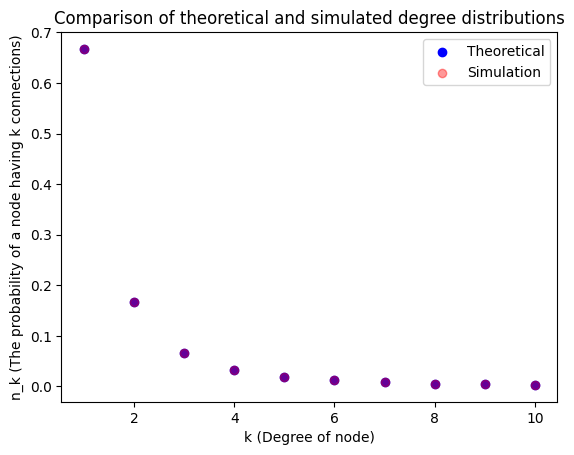

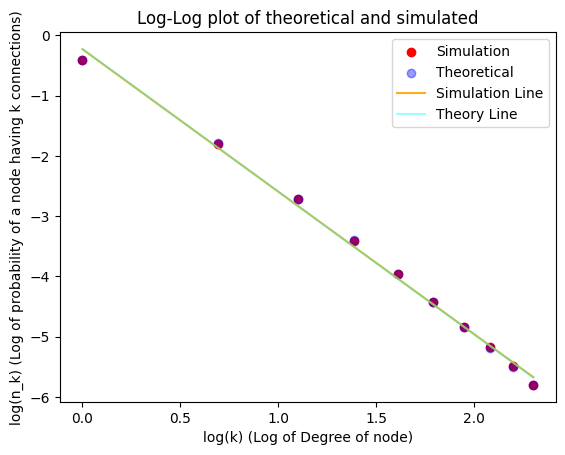

In [ ]:
# Proof of model working:
#Compare simulation n_k to theory n_k = 4 / (k * (k + 1) * (k + 2)) for r = 0.5 (Exactly when a GNR matches a GN).
num_nodes_proof = 10000
r_proof = 0.5
trials_proof = 100
k_end_proof = 10  # Example value, adjust as needed. Max value of k to plot.
N_k_sim_Proof = 0
# Run the simulation for a number of trials.
for t in range(0,trials_proof):
    N_k_sim_Proof += GNR_SimulationV2(num_nodes_proof, r_proof)
N_k_sim_Proof /= trials_proof
n_k_sim_Proof = N_k_sim_Proof / num_nodes_proof  #Normalize the number of nodes with k connections by the total number of nodes, to get the probability of nodes with k connections.

# Theoretical distribution for the proof case.
n_k_theory = np.array([ 4 / (k_i * (k_i + 1) * (k_i + 2)) for k_i in range(1, len(n_k_sim_Proof)+1)], dtype=float)

# Filter the data to only include k values up to the user selected k_end_proof, to avoid skewing the linear regression fit with the tail of the distribution.
k = np.arange(1, k_end_proof + 1)
y_theory = n_k_theory[0:k_end_proof]
y_sim = n_k_sim_Proof[1:k_end_proof+1]

# Log-Log Data Set
k_log = np.log(k)
y_log_sim = np.log(y_sim)
y_log_theory = np.log(y_theory)

# Scatter Plot of Regression of Simulation and Theory
plt.figure()
plt.scatter(k, y_theory, color="blue", label="Theoretical")
plt.scatter(k, y_sim, color="red", label="Simulation", alpha=0.4)
plt.xlabel("k (Degree of node)")
plt.ylabel("n_k (The probability of a node having k connections)")
plt.title("Comparison of theoretical and simulated degree distributions")
plt.legend()
plt.show()

# Linear Regression of Simulation and Theory for Log-Log Plot

Simulation_Line = linregress(k_log, y_log_sim)
Simulation_slope = Simulation_Line.slope
Simulation_intercept = Simulation_Line.intercept

Theory_Line = linregress(k_log, y_log_theory)
Theory_slope = Theory_Line.slope
Theory_intercept = Theory_Line.intercept

# Log-Log Plot
plt.figure()
plt.scatter(k_log, y_log_sim, color="red", label="Simulation")
plt.scatter(k_log, y_log_theory, color="blue", label="Theoretical", alpha=0.4)
plt.plot(k_log, Simulation_slope * k_log + Simulation_intercept, color="orange", label="Simulation Line", alpha=0.9)
plt.plot(k_log, Theory_slope * k_log + Theory_intercept, color="cyan", label="Theory Line", alpha=0.4)
plt.xlabel("log(k) (Log of Degree of node)")
plt.ylabel("log(n_k) (Log of probability of a node having k connections)")
plt.title("Log-Log plot of theoretical and simulated")
plt.legend()
plt.show()

Calculated a: 8003.3254
Calculated b: -2.3711


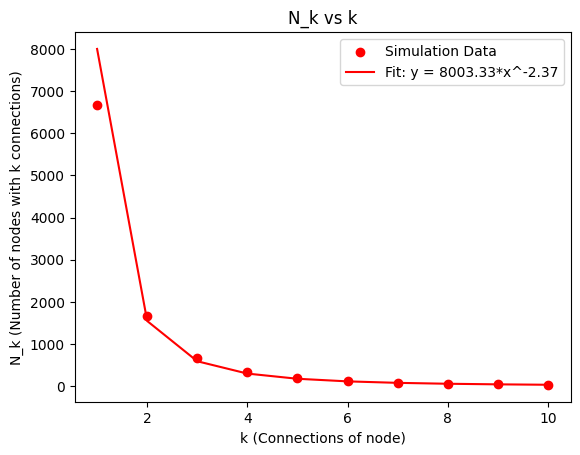

N_1:  6665.861
N_2:  1667.649
N_3:  666.692
N_4:  333.319
N_5:  190.499
N_6:  119.117
N_7:  78.958
N_8:  55.635
N_9:  40.591
N_10:  30.155


In [ ]:
# Start of Task
num_nodes = 10000
r = 0.5
trials = 1000
k_end = 10  # Example value, adjust as needed. Max value of k to plot.
k = np.arange(1, k_end + 1)
N_k = 0
# Run the simulation for a number of trials.
for t in range(0,trials):
    N_k += GNR_SimulationV2(num_nodes, r)
N_k /= trials
n_k = N_k / num_nodes  #Normalize the number of nodes with k connections by the total number of nodes, to get the probability of nodes with k connections.
y = N_k[1:k_end+1]

k_log = np.log(k)
N_k_log = np.log(N_k[1:k_end+1])

b, log_a = np.polyfit(k_log, N_k_log, 1)

# Convert intercept back to original scale 'a'
a = np.exp(log_a)

print(f"Calculated a: {a:.4f}")
print(f"Calculated b: {b:.4f}")

# Plot results
plt.figure()
plt.scatter(k, y, color="red", label="Simulation Data")
plt.plot(k, a * (k ** b), color='red', label=f"Fit: y = {a:.2f}*x^{b:.2f}")
plt.xlabel("k (Connections of node)")
plt.ylabel("N_k (Number of nodes with k connections)")
plt.title("N_k vs k")
plt.legend()
plt.show()

print('N_1: ', N_k[1])
print('N_2: ', N_k[2])
print('N_3: ', N_k[3])
print('N_4: ', N_k[4])
print('N_5: ', N_k[5])
print('N_6: ', N_k[6])
print('N_7: ', N_k[7])
print('N_8: ', N_k[8])
print('N_9: ', N_k[9])
print('N_10: ', N_k[10])

